# Intro to PyTorch for ML

In this lab, we will learn how to build, train, and evaluate neural networks from PyTorch. We will show two examples: a classification problem and a regression problem.

### Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

# Model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score


# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

The first task is a binary classification task. The goal is to predict whether a client will subscribe to a term deposit based on the given features. \
The target variable `y` is a categorical variable with 2 classes: `no` and `yes`. \
The features include age of the client, job, education etc. \
Let's load the dataset first and see its structure.

In [2]:
import zipfile
import io
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

# download zip
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))

# read specific csv inside the zip
with z.open('bank-additional/bank-additional.csv') as f:
    df = pd.read_csv(f, sep=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
df.shape

(4119, 21)

We can see that our data contains 21 columns and 4119 rows. The columns are our features including the target column, while every row is a sample (client).

In [4]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


Our data contains both numerical types (int64, float64) and categorical data (object). A bit later, we will need to encode these values since PyTorch models work with numerical data.

### Handling missing data

In [5]:
df = df.fillna(0)

In case we have missing/NaN values, we always need to handle how we want to deal with them. Here, we replace them with 0.

Note: We could also replace them with the mean/median of the feature or remove rows with too many missing values.

### Encoding categorical features

Neural networks require numeric input, so we encode categorical features.
The most common ways to do this is either using `LabelEncoder` or `OneHotEncoder`.

`LabelEncoder` converts each category to a number, for example: \
yes -> 1 \
no -> 0

or

married -> 0 \
single -> 1 \
divorced -> 2,

but these categories semantically don't have any order. That's why we use `OneHotEncoder`.



In [6]:
target = 'y'

categorical_cols = df.select_dtypes(include=['object']).columns.drop('y')
numerical_cols = df.select_dtypes(exclude=['object']).columns

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

df_cat = pd.DataFrame(
    ohe.fit_transform(df[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols)
)

df_num = df[numerical_cols].reset_index(drop=True)
df_target = df[['y']].reset_index(drop=True)

df_processed = pd.concat([df_num, df_cat, df_target], axis=1)

df_processed.head()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,no
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,no


Next, we want to split the data into train, validation, and test sets.

- **Training set (70%)**: Used to train the model (update weights)
- **Validation set (15%)**: Used during training to monitor performance and tune hyperparameters
- **Test set (15%)**: Used only at the end for final evaluation

This way, the test set remains completely unseen during training, giving us an unbiased estimate of model performance.

In [7]:
# First split: 70% train, 30% temp (which will be split into val and test)
df_train, df_temp = train_test_split(df_processed, test_size=0.3, random_state=42)

# Second split: split temp into 50-50, giving us 15% val and 15% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(df_train)} ({len(df_train)/len(df_processed)*100:.1f}%)")
print(f"Validation size: {len(df_val)} ({len(df_val)/len(df_processed)*100:.1f}%)")
print(f"Test size: {len(df_test)} ({len(df_test)/len(df_processed)*100:.1f}%)")

Train size: 2883 (70.0%)
Validation size: 618 (15.0%)
Test size: 618 (15.0%)


### Scaling the data
Neural networks train better when inputs are on a similar scale. \
If one feature ranges from 0–1000 and another from 0–1, the model can become biased toward the larger-valued feature. Normalization helps prevent this. \
We use `MinMaxScaler`, which scales features to the range [0, 1].

In [8]:
scaler = MinMaxScaler()

# Fit the scaler only on training data
scaler.fit(df_train[numerical_cols])

# Transform all three sets using the fitted scaler
df_train[numerical_cols] = scaler.transform(df_train[numerical_cols])
df_val[numerical_cols] = scaler.transform(df_val[numerical_cols])
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

We convert the target class to 0s and 1s.

In [9]:
df_train['y'] = (df_train['y'] == 'yes').astype(int)
df_val['y'] = (df_val['y'] == 'yes').astype(int)
df_test['y'] = (df_test['y'] == 'yes').astype(int)

df_train.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y
926,0.228571,0.041449,0.035714,1.0,0.0,0.333333,0.340608,0.154812,0.174603,0.512287,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3855,0.528571,0.031018,0.035714,1.0,0.0,0.937500,0.698753,0.602510,0.957370,0.859735,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
997,0.214286,0.310733,0.035714,1.0,0.0,0.937500,0.698753,0.602510,0.956916,0.859735,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3128,0.200000,0.024430,0.142857,1.0,0.0,1.000000,0.669135,0.338912,0.980952,1.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1953,0.371429,0.048586,0.000000,1.0,0.0,0.937500,0.698753,0.602510,0.957370,0.859735,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0


Our setup is done, we are ready to move on to training!

### Training

PyTorch models expect tensors (multi-dimensional arrays). We convert the pandas DataFrames into tensors. We do this with `torch.tensor()`.

`dtype=torch.float` is required because neural networks use floating point arithmetic.

### DataLoaders

Instead of feeding all data at once, we use **DataLoaders** to load data in batches. This is important for:
- **Memory efficiency**: Large datasets won't fit in memory all at once
- **Better generalization**: Mini-batch training introduces noise that can help the model generalize
- **Faster training**: GPUs process batches efficiently

A DataLoader wraps a dataset and provides batching, shuffling, and parallel data loading.

In [10]:
X_train = df_train.drop(columns=['y'])
y_train = df_train[['y']]

X_val = df_val.drop(columns=['y'])
y_val = df_val[['y']]

X_test = df_test.drop(columns=['y'])
y_test = df_test[['y']]

X_train_t = torch.tensor(X_train.values, dtype=torch.float)
y_train_t = torch.tensor(y_train.values, dtype=torch.float)

X_val_t = torch.tensor(X_val.values, dtype=torch.float)
y_val_t = torch.tensor(y_val.values, dtype=torch.float)

X_test_t = torch.tensor(X_test.values, dtype=torch.float)
y_test_t = torch.tensor(y_test.values, dtype=torch.float)

print(f"Train samples: {X_train_t.shape[0]}")
print(f"Validation samples: {X_val_t.shape[0]}")
print(f"Test samples: {X_test_t.shape[0]}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Train samples: 2883
Validation samples: 618
Test samples: 618

Batch size: 64
Number of training batches: 46
Number of validation batches: 10
Number of test batches: 10


### Defining the Neural Network

We define a simple shallow neural network with the following architecture:

Linear layer → ReLU → Linear layer → Sigmoid

The hidden layer uses a ReLU activation to introduce non-linearity, while the output layer uses a Sigmoid activation to produce values between 0 and 1, which can be interpreted as probabilities for the positive class.

ReLU (Rectified Linear Unit) is one of the most common activation functions. It keeps positive values and sets negative values to 0: \
ReLU(x)=max(0,x)


This helps the network learn non-linear patterns without being too complex.

The Sigmoid function is used in the output layer because this is a binary classification problem. Sigmoid maps the network output to the range [0, 1], allowing it to be interpreted as the probability that a sample belongs to the positive class.

In [11]:
class Net(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)
        self.activation = nn.ReLU()
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.out_act(self.linear2(x))
        return x


We initialize the model and check the number of trainable parameters

In [12]:
D_in, D_out = X_train_t.shape[1], y_train_t.shape[1]
model = Net(D_in, 100, D_out)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params}")

Trainable parameters: 6501


### Loss Function and Optimizer

**Loss function** is a function that measures the difference between the predicted and true values. \
For binary classification, we use `Binary Cross-Entropy (BCE)` loss.
BCE compares the predicted probabilities (0 to 1) to the true labels (0 or 1) and penalizes incorrect predictions. Smaller BCE means the model is performing better.

An **optimizer** updates the model weights using gradients. We use `Adam`, an adaptive optimizer that adjusts learning rates for each parameter automatically. \
`lr` (learning rate) controls the step size of each update. A too-large lr can cause training to diverge. \
`weight_decay` (L2 regularization) penalizes large weights to prevent overfitting. It adds a penalty term to the loss function.

In [13]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

This following loop trains the model for 200 epochs (iterations).

Steps in each epoch:
1. **Training phase**: Iterate through batches from the training DataLoader
   - Forward pass: compute predictions on each batch
   - Compute loss for the batch
   - Backward pass: compute gradients
   - Update weights using optimizer
2. **Validation phase**: Iterate through validation batches (without updating weights) to monitor generalization

Note: We use the validation set during training to monitor performance. The test set is reserved for final evaluation.

In [14]:
losses_train = []
losses_val = []

for epoch in range(200):
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        # forward pass
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * batch_X.size(0)

    # average training loss for the epoch
    epoch_train_loss /= len(train_loader.dataset)
    losses_train.append(epoch_train_loss)

    # validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_pred = model(batch_X)
            val_loss = criterion(val_pred, batch_y)
            epoch_val_loss += val_loss.item() * batch_X.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    losses_val.append(epoch_val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Train loss: {epoch_train_loss:.4f} | Val loss: {epoch_val_loss:.4f}")

Epoch 0 | Train loss: 0.4362 | Val loss: 0.3028
Epoch 50 | Train loss: 0.1295 | Val loss: 0.2287
Epoch 100 | Train loss: 0.0777 | Val loss: 0.2659
Epoch 150 | Train loss: 0.0499 | Val loss: 0.3107


For better understanding, we will visualize the training process by plotting the training and validation loss.

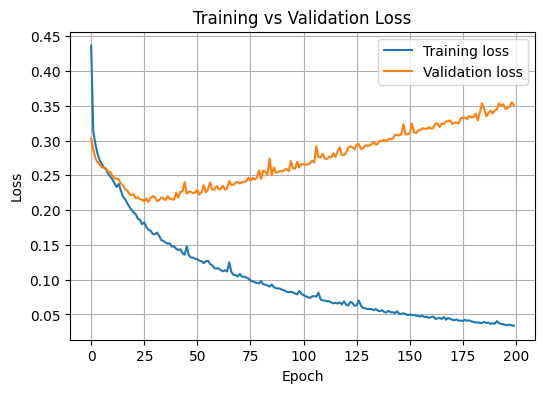

In [15]:
plt.figure(figsize=(6,4))
plt.plot(losses_train, label='Training loss')
plt.plot(losses_val, label='Validation loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Training loss decreases → the model is learning from the training data.  
Validation loss decreases too → the model generalizes well to unseen data.

When validation loss starts increasing while training loss decreases, it means the model is overfitting (memorizing training data rather than learning general patterns).

In [16]:
# Final evaluation on the test set (unseen data)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_pred = model(batch_X)
        all_preds.append(batch_pred)
        all_labels.append(batch_y)

y_test_pred = torch.cat(all_preds)
y_test_t = torch.cat(all_labels)
y_test_labels = (y_test_pred > 0.5).float()
accuracy = (y_test_labels == y_test_t).float().mean()

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.9029126167297363


The test accuracy measures the proportion of samples that the model correctly classified. Let's check the first 5 predictions and compare them with the true labels.

In [17]:
print("Predicted probabilities (first 5):", y_test_pred[:5].numpy().flatten())
print("Predicted classes (first 5):", y_test_labels[:5].numpy().flatten())
print("True values (first 5):", y_test_t[:5].numpy().flatten())

Predicted probabilities (first 5): [3.5498901e-03 1.8228239e-03 9.1390825e-07 9.2597986e-03 1.6838741e-01]
Predicted classes (first 5): [0. 0. 0. 0. 0.]
True values (first 5): [0. 0. 0. 0. 0.]


Accuracy isn't always the best metric, especially when it comes to imbalanced datasets. Let's look at the distribution of the target variable first.

In [18]:
df['y'].value_counts(normalize=False)

,count
y,
no,3668
yes,451


The ROC curve (Receiver Operating Characteristic curve) shows the performance of a binary classifier across all possible classification thresholds.

X-axis: False Positive Rate (FPR) – proportion of negative samples incorrectly classified as positive. \
Y-axis: True Positive Rate (TPR, or sensitivity) – proportion of positive samples correctly classified.

Each point on the curve corresponds to a different threshold for deciding whether a sample is classified as positive.

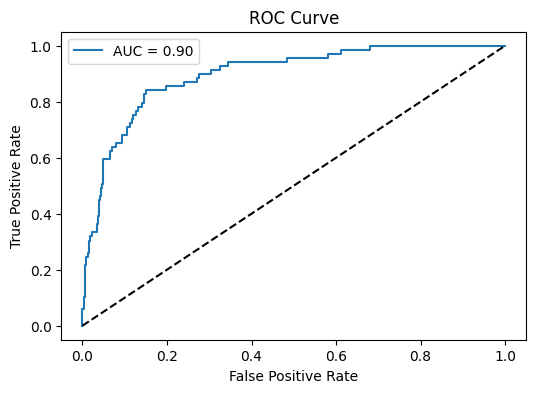

In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_t.numpy(), y_test_pred.numpy())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


We will now experiment with different numbers of hidden neurons in the network to see how the model’s capacity affects performance. Let's compare multiple metrics for each model and see how well each hidden layer size captures patterns in the data.
We will compute accuracy, precision, recall and F1 score.
- Accuracy: The fraction of all predictions that the model got correct; can be misleading on imbalanced datasets.

- Precision: The fraction of positive predictions that are actually correct; measures reliability of positive predictions.

- Recall (Sensitivity): The fraction of actual positives that the model correctly identifies; measures how well the model finds positive cases.

- F1 Score: The harmonic mean of precision and recall; balances both metrics into a single score.

- AUC: Measures the model’s ability to rank positives higher than negatives across all thresholds; threshold-independent and robust to class imbalance.

In [20]:
hidden_sizes = [100, 200, 300, 500]

results = {}

for H in hidden_sizes:
    print(f"\nTraining model with {H} hidden neurons")

    model = Net(D_in, H, D_out)

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Training loop
    for epoch in range(200):
        model.train()
        for batch_X, batch_y in train_loader:
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate on test set
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_pred = model(batch_X)
            all_preds.append(batch_pred)
            all_labels.append(batch_y)

    y_test_pred = torch.cat(all_preds)
    y_test_t = torch.cat(all_labels)
    y_test_labels = (y_test_pred > 0.5).float()
    auc = roc_auc_score(y_test_t.numpy(), y_test_pred.numpy())

    accuracy = (y_test_labels == y_test_t).float().mean()
    precision = precision_score(y_test_t, y_test_labels)
    recall = recall_score(y_test_t, y_test_labels)
    f1 = f1_score(y_test_t, y_test_labels)

    print(f"Hidden neurons: {H} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f} | "
        f"AUC: {auc:.2f} | "
        f"Accuracy: {accuracy:.2f}")

    results[H] = (precision, recall, f1)



Training model with 100 hidden neurons
Hidden neurons: 100 | Precision: 0.58 | Recall: 0.42 | F1: 0.49 | AUC: 0.91 | Accuracy: 0.90

Training model with 200 hidden neurons
Hidden neurons: 200 | Precision: 0.52 | Recall: 0.49 | F1: 0.50 | AUC: 0.89 | Accuracy: 0.89

Training model with 300 hidden neurons
Hidden neurons: 300 | Precision: 0.59 | Recall: 0.54 | F1: 0.56 | AUC: 0.89 | Accuracy: 0.91

Training model with 500 hidden neurons
Hidden neurons: 500 | Precision: 0.60 | Recall: 0.46 | F1: 0.52 | AUC: 0.89 | Accuracy: 0.91


Recall is consistently low indicating that the model fails to identify a large proportion of actual positive cases (clients who would subscribe to the term deposit).

Precision is moderate meaning that when the model predicts a positive outcome, the prediction is often—but not always—correct.

The F1 score, which combines precision and recall into a single metric, remains relatively low across all models. This highlights the difficulty of accurately detecting the minority class in the presence of strong class imbalance.

In contrast, the AUC is high for all hidden layer sizes, suggesting that the model is effective at ranking positive samples higher than negative ones, even though a fixed decision threshold leads to poor recall.

### Regression

Now, we will briefly show how to use PyTorch for a regression problem. This means we are trying to predict a continuous value. We will be using the Boston Housing dataset, which contains information about houses in Boston and their prices.

Our target variable is `medv`, which is the median value of owner-occupied homes in thousands of dollars, so the goal of our model is to learn the relationship between the input features and the median house value. \
Our features include crim (per capita crime rate), rm (average number of rooms per dwelling), dis (weighted distance to employment centers) etc.

Let's load the data and take a look at it.


In [21]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [22]:
df.shape

(506, 14)

In [23]:
df.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


We can see that all the features are already numerical, so we don't need to do any feature engineering. \
Let's check if there are any missing values:

In [24]:
df.isna().any().any()

np.False_

In [25]:
target = "medv"
X = df.drop(columns=[target]).values
y = df[target].values.reshape(-1, 1)

We split the dataset into train (70%), validation (15%), and test (15%) sets.

In [26]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train size: 354 (70.0%)
Validation size: 76 (15.0%)
Test size: 76 (15.0%)


As before, we need to scale the data. This time, we will show `StandardScaler`. StandardScaler rescales each feature by subtracting its mean and dividing by its standard deviation, so the feature ends up with mean 0 and variance 1. This puts all features on the same scale without changing their relative distributions.

In [27]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scalers only on training data
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Transform validation and test data using the fitted scalers
X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

We convert the data to pytorch tensors and create DataLoaders for batch processing.

In [28]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

print(f"Train samples: {X_train_t.shape[0]}")
print(f"Validation samples: {X_val_t.shape[0]}")
print(f"Test samples: {X_test_t.shape[0]}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Train samples: 354
Validation samples: 76
Test samples: 76

Batch size: 32
Number of training batches: 12
Number of validation batches: 3
Number of test batches: 3


Let's see a slightly bigger neural network. The neural network for this task contains 4 linear layers total: 3 hidden layers (128, 64, 32 units) each followed by ReLU, and 1 output layer.

In [29]:
class Net(nn.Module):
    def __init__(self, D_in, H1, H2, H3, D_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D_in, H1),
            nn.ReLU(),
            nn.Linear(H1, H2),
            nn.ReLU(),
            nn.Linear(H2, H3),
            nn.ReLU(),
            nn.Linear(H3, D_out)
        )

    def forward(self, x):
        return self.net(x)

D_in is the number of input features in the dataset. D_out = 1 because this is a regression task with a single continuous target value. The network predicts one scalar per sample.

For our criterion, we use the mean squared error (MSE) loss, which is a common choice for regression tasks. Mean Squared Error (MSE) is the average of the squares of the differences between predicted and true values. MSE penalizes larger errors more heavily, which is standard for regression tasks.

For the optimizer, we use Adam again. Another popular choice for optimization is SGD (Stochastic Gradient Descent). SGD updates the model parameters in the direction of the steepest gradient of the loss function, but it can be unstable and slower to converge.

In [30]:
D_in = X_train_t.shape[1]
D_out = 1
model = Net(D_in, 128, 64,32, D_out)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)

Now let's train the model using DataLoaders and plot the loss function for training and validation data.

Epoch 0: Train Loss = 0.5657, Val Loss = 0.1662
Epoch 20: Train Loss = 0.0722, Val Loss = 0.0726
Epoch 40: Train Loss = 0.0420, Val Loss = 0.0799
Epoch 60: Train Loss = 0.0428, Val Loss = 0.0727
Epoch 80: Train Loss = 0.0310, Val Loss = 0.0607


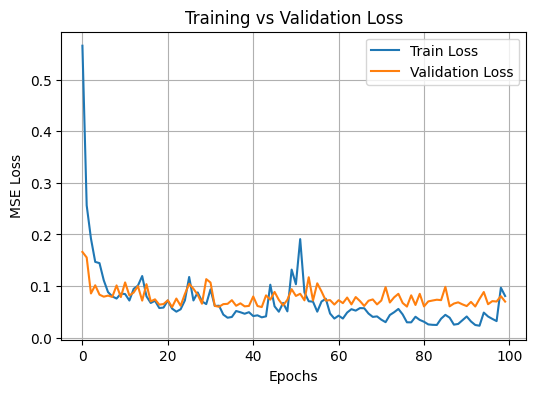

In [31]:
losses_train = []
losses_val = []

for epoch in range(100):
    # Training
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    losses_train.append(epoch_train_loss)

    # Validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_pred = model(batch_X)
            val_loss = criterion(val_pred, batch_y)
            epoch_val_loss += val_loss.item() * batch_X.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    losses_val.append(epoch_val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss = {epoch_train_loss:.4f}, Val Loss = {epoch_val_loss:.4f}")


plt.figure(figsize=(6,4))
plt.plot(losses_train, label="Train Loss")
plt.plot(losses_val, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

From the loss curves above, we observe that the training loss decreases, indicating that the model is fitting the training data well. We monitor the validation loss to check if the model generalizes well.

The validation loss starts to increase while training loss keeps decreasing, this is a clear sign of **overfitting**. The model begins to memorize patterns and noise specific to the training data rather than learning relationships that generalize well to unseen data.

Common strategies to mitigate overfitting are:
- Early stopping (stop training when validation loss starts increasing)
- Stronger regularization (increase weight_decay)
- Reducing model complexity (fewer hidden neurons/layers)
- Adding dropout layers

Now let's evaluate on the test set. We can compare the predicted vs true values for the first 5 samples:

In [32]:
model.eval()
all_preds = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_pred = model(batch_X)
        all_preds.append(batch_pred)

y_test_pred = torch.cat(all_preds)

y_test_pred_unscaled = scaler_y.inverse_transform(y_test_pred.numpy())
y_test_true_unscaled = scaler_y.inverse_transform(y_test_t.numpy())

print("Predictions (first 5):", y_test_pred_unscaled[:5].flatten())
print("True values (first 5):", y_test_true_unscaled[:5].flatten())


Predictions (first 5): [28.838064  12.4313135 26.89622   20.35084   17.298428 ]
True values (first 5): [30.8 17.1 50.  20.9 16.1]


Let's visualise the true and predicted values of each sample in the dataset in a scatter plot. The closer the points are to the line y = x, the better the model is performing.

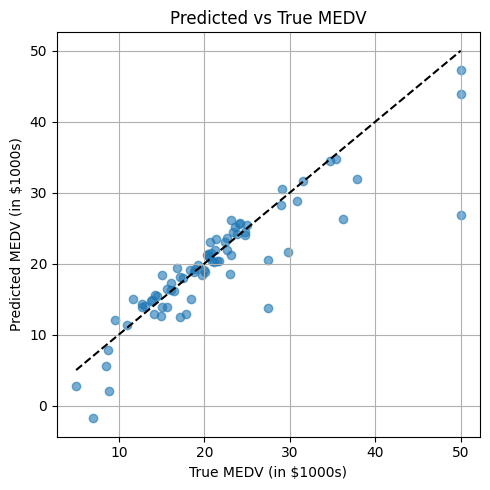

In [33]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_true_unscaled, y_test_pred_unscaled, alpha=0.6)
plt.plot(
    [y_test_true_unscaled.min(), y_test_true_unscaled.max()],
    [y_test_true_unscaled.min(), y_test_true_unscaled.max()],
    "k--"
)
plt.xlabel("True MEDV (in $1000s)")
plt.ylabel("Predicted MEDV (in $1000s)")
plt.title("Predicted vs True MEDV")
plt.tight_layout()
plt.grid()
plt.show()


As done in the classification example, we will now experiment with different hidden layer sizes to find the best performing model.

In [34]:
hidden_sizes = [(50, 25, 12), (100, 50, 25), (200, 100, 50), (300, 150, 75), (400, 200, 100)]
results = {}

for H1, H2, H3 in hidden_sizes:
    print(f"\nTraining model with hidden neurons {H1}, {H2}, {H3}")

    model = Net(D_in, H1, H2, H3, D_out)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    # Train
    for epoch in range(100):
        model.train()
        for batch_X, batch_y in train_loader:
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate on test set
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_pred = model(batch_X)
            all_preds.append(batch_pred)

    y_test_pred = torch.cat(all_preds)

    # Inverse scaling
    y_pred_unscaled = scaler_y.inverse_transform(y_test_pred.numpy())
    y_true_unscaled = scaler_y.inverse_transform(y_test_t.numpy())

    rmse = np.sqrt(np.mean((y_pred_unscaled - y_true_unscaled) ** 2))
    results[(H1, H2, H3)] = rmse

    print(f"Hidden neurons: {H1}-{H2}-{H3} | RMSE: {rmse:.2f}")



Training model with hidden neurons 50, 25, 12
Hidden neurons: 50-25-12 | RMSE: 3.88

Training model with hidden neurons 100, 50, 25
Hidden neurons: 100-50-25 | RMSE: 3.80

Training model with hidden neurons 200, 100, 50
Hidden neurons: 200-100-50 | RMSE: 3.50

Training model with hidden neurons 300, 150, 75
Hidden neurons: 300-150-75 | RMSE: 3.35

Training model with hidden neurons 400, 200, 100
Hidden neurons: 400-200-100 | RMSE: 3.65


### Summary

In this lab, we explored how neural networks can be trained and evaluated using PyTorch through both classification and regression problems. The classification task highlighted the challenges posed by real-world data, particularly class imbalance. Although the models achieved high accuracy, a deeper analysis using precision, recall, F1 score, and AUC revealed that accuracy alone was misleading and that the models struggled to correctly identify the minority class.

The regression task further illustrated how model complexity and training duration influence generalization. By examining training and test loss curves, as well as predicted versus true values, we observed clear signs of overfitting.

Overall, we have to remember that building neural networks is not only about defining architectures and optimizing loss functions, but also about critically interpreting results, diagnosing issues such as class imbalance and overfitting, and making informed decisions about model evaluation and selection..